In [1]:
import numpy as np

In [2]:
%env JAX_ENABLE_X64=True

env: JAX_ENABLE_X64=True


In [3]:
from lenstronomy.LensModel.lens_model import LensModel
import lensinggw.constants.constants as const
from lensinggw.utils.utils import TimeDelay, magnifications, getMinMaxSaddle

In [4]:
import sys
import os
path = os.getcwd()
dir = os.path.abspath(os.path.join(path, os.pardir))
sys.path.append(dir)

In [7]:
from wolensing.plot.plot import plot_contour
import wolensing.amplification_factor.amplification_factor as af
from wolensing.lensmodels.potential import potential

The macroimage where the microlens is placed around.

In [8]:
type2 = False

In [9]:
ym = 0.8
angle = np.radians(float(0))

Importing constants

In [10]:
G = const.G  # gravitational constant [m^3 kg^-1 s^-2]
c = const.c  # speed of light [m/s]
M_sun = const.M_sun  # Solar mass [Kg]

In [11]:
y0, y1 = 0.5, 0 # source position
l0, l1 = 0., 0 # lens position

zS = 1.0 # source redshift
zL = 0.5 # lens redshift

In [12]:
mL1 = 1e10
mL2 = 20
mtot = mL1 + mL2

# convert to radians
from lensinggw.utils.utils import param_processing
thetaE1 = param_processing(zL, zS, mL1)
thetaE2 = param_processing(zL, zS, mL2)
thetaE = param_processing(zL, zS, mtot)

In [13]:
thetaE

8.052888069635299e-07

In [14]:
Mpc=3.085677581491367e+22
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=69.7, Om0=0.306, Tcmb0=2.725)
DL       = cosmo.angular_diameter_distance(zL)
DS       = cosmo.angular_diameter_distance(zS)
DLS      = cosmo.angular_diameter_distance_z1z2(zL, zS)
D        = DLS/(DL*DS)
print(np.float64(D/Mpc))

1.097926071881248e-26


In [20]:
from wolensing.utils.utils import Einstein_radius

In [21]:
Einstein_radius(zL, zS, mtot)

141457.81166301022

In [22]:
beta0, beta1 = y0 * thetaE, y1 * thetaE
eta10, eta11 = 0 * l0 * thetaE, 0 * l1 * thetaE
lens_model_list = ['SIS']
kwargs_sis_1 = {'center_x': eta10, 'center_y': eta11, 'theta_E': thetaE1}
kwargs_lens_list = [kwargs_sis_1]

kwargs_sis_1_scaled = {'center_x': eta10 / thetaE, 'center_y': eta11 / thetaE, 'theta_E': thetaE1 / thetaE}
kwargs_lens_list_scaled = [kwargs_sis_1_scaled]

from lensinggw.solver.images import microimages
solver_kwargs = {'SearchWindowMacro': 10 * thetaE1,
                 'SearchWindow': 5 * thetaE2,
                 'OverlapDistMacro': 1e-17,
                 'OnlyMacro': True}
MacroImg_ra, MacroImg_dec, pixel_width = microimages(source_pos_x=beta0,
                                                     source_pos_y=beta1,
                                                     lens_model_list=lens_model_list,
                                                     kwargs_lens=kwargs_lens_list,
                                                     **solver_kwargs)

Td = TimeDelay(MacroImg_ra, MacroImg_dec,
                beta0, beta1,
                zL, zS,
                lens_model_list, kwargs_lens_list)
Mus = magnifications(MacroImg_ra, MacroImg_dec, lens_model_list, kwargs_lens_list)
if type2:
    microtype = np.nonzero(Td)[0][0]
else:
    microtype = np.where(Td==0)[0][0]

masses = [60]
angle = [0]
ym = [.4]

num_points = len(masses)
for j in range(0,num_points):
    theta_E = param_processing(zL, zS, masses[j])# lens model
    #positioning the microlenses
    eta20 = MacroImg_ra[microtype] + ym[j]*np.cos(np.radians(angle[j])) * theta_E
    eta21 = MacroImg_dec[microtype] + ym[j] * np.sin(np.radians(angle[j])) * theta_E
    lens_model_list.append('POINT_MASS')
    kwargs_lens_list.append({'center_x': eta20, 'center_y': eta21, 'theta_E': theta_E})

# mass_density = 100
# from utils.lensing import *
# radius = injection_radius(masses, mass_density) #rad
# lens_model_list, kwargs_lens_list = field_injection(zL, zS, MacroImg_ra[microtype], MacroImg_dec[microtype], masses, radius, lens_model_list, kwargs_lens_list, seed=1)
    
# Injecting microlens around desired macroimage
# eta20, eta21 = MacroImg_ra[microtype] + np.cos(angle)*ym*thetaE2, MacroImg_dec[microtype] + np.sin(angle)*ym*thetaE2
# lens_model_list = ['SIS', 'POINT_MASS']
# kwargs_sis_1 = {'center_x': eta10, 'center_y': eta11, 'theta_E': thetaE1}
# kwargs_point_mass_2 = {'center_x': eta20, 'center_y': eta21, 'theta_E': thetaE2}
# kwargs_lens_list = [kwargs_sis_1, kwargs_point_mass_2]

from lensinggw.solver.images import microimages
solver_kwargs = {'SearchWindowMacro': 10 * thetaE1,
                 'SearchWindow': 40 * thetaE2,
                 'Pixels': 5*1e3,
                 # 'ImgIndex': 1,
                 'Optimization': True,
                 'OverlapDist': 1e-18,
                 'OverlapDistMacro': 1e-17}
solver_kwargs.update({'Improvement' : 0.1})
solver_kwargs.update({'MinDist' : 10**(-7)})

Img_ra, Img_dec, MacroImg_ra, MacroImg_dec, pixel_width = microimages(source_pos_x=beta0,
                                                                      source_pos_y=beta1,
                                                                      lens_model_list=lens_model_list,
                                                                      kwargs_lens=kwargs_lens_list,
                                                                      **solver_kwargs)
# Images_dict = {'Source_ra': beta0,
#                'Source_dec': beta1,
#                'Img_ra': Img_ra,
#                'Img_dec': Img_dec,
#                'MacroImg_ra': MacroImg_ra,
#                'MacroImg_dec': MacroImg_dec,
#                'Microlens_ra': [eta20],
#                'Microlens_dec': [eta21],
#                'thetaE': thetaE}

# time delays, magnifications, Morse indices 
from lensinggw.utils.utils import TimeDelay, magnifications, getMinMaxSaddle
from lensinggw.amplification_factor.amplification_factor import geometricalOpticsMagnification
tds = TimeDelay(Img_ra, Img_dec,
               beta0, beta1,
               zL, zS,
               lens_model_list, kwargs_lens_list)
mus = magnifications(Img_ra, Img_dec, lens_model_list, kwargs_lens_list)
ns = getMinMaxSaddle(Img_ra, Img_dec, lens_model_list, kwargs_lens_list, diff = None)
print('Time delays (seconds): ', tds)
print('magnifications: ', mus)
print('Morse indices: ', ns)
    
lens_model_complete = LensModel(lens_model_list=lens_model_list)
T = lens_model_complete.fermat_potential
T0 = thetaE ** (-2) * T(Img_ra[microtype], Img_dec[microtype], kwargs_lens_list, beta0, beta1)#[0]
if not isinstance(T0, float):
    T0 = T0[0]
Tscale = 4 * (1 + zL) * mtot * M_sun * G / c ** 3
print('T0 = {}'.format(T0))
print('Tscale = {}'.format(Tscale))

/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/lensinggw-1.0.0-py3.10.egg/lensinggw/solver/images.py:107: SyntaxWarning: "is not" with a literal. Did you mean "!="?
/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/lensinggw-1.0.0-py3.10.egg/lensinggw/solver/images.py:107: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/lensinggw-1.0.0-py3.10.egg/lensinggw/solver/images.py:108: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/lensinggw-1.0.0-py3.10.egg/lensinggw/solver/images.py:117: SyntaxWarning: "is not" with a literal. Did you mean "!="?
/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/lensinggw-1.0.0-py3.10.egg/lensinggw/solver/images.py:117: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packa


---- Will perform only the macromodel analysis ----

---- Solver settings ----

The macromodel analysis will be performed with the following settings:

OnlyMacro         --> True
Scaled            --> False
SearchWindowMacro --> 8.052888061582412e-06
PixelsMacro       --> 1000
PrecisionLimit    --> 1e-20
OverlapDistMacro  --> 1e-17
NearSource        --> False
Optimization      --> False
Verbose           --> False




MACROIMAGES

ra: [-4.02644403e-07  1.20793321e-06]
dec: [-4.23516474e-22 -4.23516474e-22]


---- Solver settings ----

The macromodel analysis will be performed with the following settings:

OnlyMacro                       --> False
Scaled                          --> False
SearchWindowMacro               --> 8.052888061582412e-06
PixelsMacro                     --> 1000
OverlapDistMacro                --> 1e-17
NearSource                      --> False
Optimization                    --> True
Verbose                         --> False
OptimizationWindowMacro         --> 

In [23]:
Img_ra = np.delete(Img_ra, [0])
Img_dec = np.delete(Img_dec, [0])

In [24]:
# from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
# from lenstronomy.LensModel.lens_model import LensModel
# lensmodel = LensModel(lens_model_list=lens_model_list)
# solver = LensEquationSolver(
#     lensModel = lensmodel
# )
# Img_ra, Img_dec = solver.image_position_stochastic(
#     source_x = beta0,
#     source_y = beta1,
#     kwargs_lens = kwargs_lens_list,
#     # min_distance = 1e-13,
#     # solver='lenstronomy'
#     search_window = 20*thetaE2,
#     # verbose=True,
#     precision_limit=10**(-17),
#     x_center = MacroImg_ra[microtype],
#     y_center= MacroImg_dec[microtype]
# )

In [25]:
# Img_ra, Img_dec

In [26]:
lens_model_complete = LensModel(lens_model_list=lens_model_list)
T = lens_model_complete.fermat_potential
T0 = thetaE ** (-2) * T(Img_ra[microtype], Img_dec[microtype], kwargs_lens_list, beta0, beta1)#[0]

[-4.02644403e-07  1.20793321e-06] [-4.23516474e-22 -4.23516474e-22] Img_pos


<Axes: >

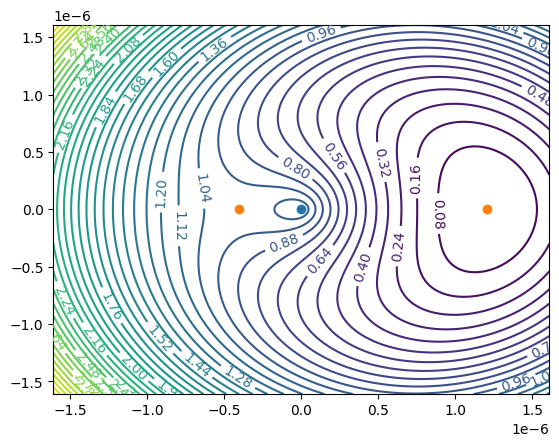

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plot_contour(ax, lens_model_list, eta10, eta11, 4*thetaE1, kwargs_lens_list, beta0, beta1, MacroImg_ra, MacroImg_dec,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=False)


[1.20792073e-06 1.20792073e-06 1.20788207e-06 1.20800930e-06] [-1.01351045e-10  1.01351045e-10 -5.71347436e-22 -5.71347436e-22] Img_pos


<Axes: >

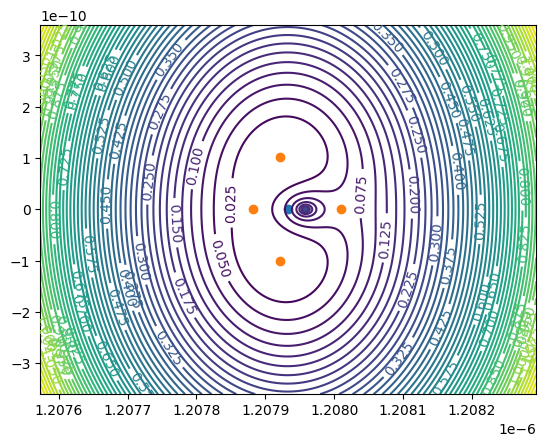

In [28]:
fig1, ax1 = plt.subplots()
plot_contour(ax1, lens_model_list, MacroImg_ra[microtype], MacroImg_dec[microtype], 20*thetaE2, kwargs_lens_list, beta0, beta1, Img_ra, Img_dec,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=True)

In [29]:
Tscale = 4 * (1 + zL) * mtot * M_sun * G / c ** 3
MacroImg_ra[1]

1.2079332096400056e-06

In [30]:
# from lenstronomy.Plots.lens_plot import lens_model_plot
# fig2, ax2 = plt.subplots()

# lens_model_plot(ax2, lensmodel, kwargs_lens_list, sourcePos_x = beta0, sourcePos_y=beta1,  with_caustics=True, coord_center_ra = MacroImg_ra[1],coord_center_dec = MacroImg_dec[1])

In [31]:
# from lenstronomy.Plots.lens_plot import arrival_time_surface
# fig3, ax3 = plt.subplots()

# arrival_time_surface(ax3, lensmodel, kwargs_lens_list,sourcePos_x = beta0, sourcePos_y=beta1, with_caustics=True)

In [32]:
# kwargs_lens_list1 = [{'center_x': 1.2079581606010867e-06,
#   'center_y': -4.235164736271502e-22,
#   'theta_E': 6.237740270276241e-11}]

In [33]:
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# lens_model_list = ['POINT_MASS']
lens_model_complete = LensModel(lens_model_list=lens_model_list)
lensmodelext = LensModelExtensions(lens_model_complete)
ra_crit_list, dec_crit_list = lensmodelext.critical_curve_tiling(kwargs_lens_list, compute_window=10*thetaE2, start_scale = thetaE2/100, center_x=MacroImg_ra[1], center_y=MacroImg_dec[1])

In [34]:
ra_caustic_list, dec_caustic_list = lens_model_complete.ray_shooting(ra_crit_list, dec_crit_list, kwargs_lens_list)

In [35]:
macro_srcx, macro_srcy = lens_model_complete.ray_shooting(MacroImg_ra, MacroImg_dec, kwargs_lens_list)

In [36]:
lens_srcx, lens_srcy = lens_model_complete.ray_shooting(eta20, eta21, kwargs_lens_list)

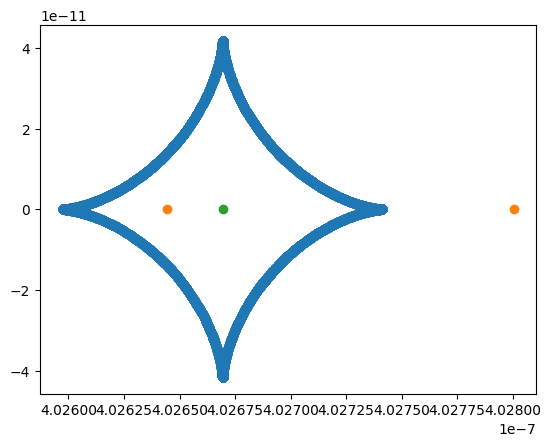

In [37]:
# plt.scatter(ra_crit_list, dec_crit_list)
# plt.scatter(MacroImg_ra[1], MacroImg_dec[1])
# plt.scatter(eta20, eta21)
# plt.scatter(Img_ra, Img_dec)
plt.scatter(ra_caustic_list, dec_caustic_list)
plt.scatter(macro_srcx, macro_srcy)
plt.scatter(lens_srcx, lens_srcy)

[1.20792073e-06 1.20792073e-06 1.20788207e-06 1.20800930e-06] [-1.01351045e-10  1.01351045e-10 -5.71347436e-22 -5.71347436e-22] Img_pos


AttributeError: PathCollection.set() got an unexpected keyword argument 'markersize'

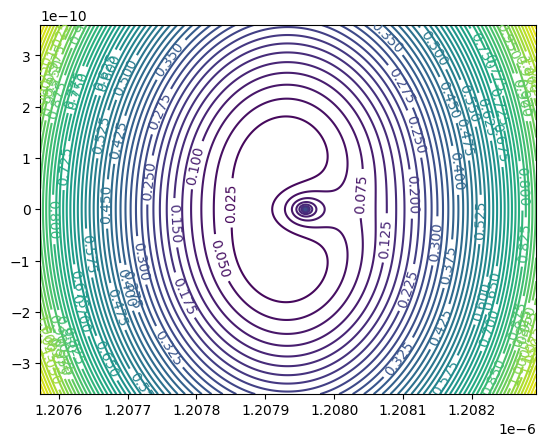

In [38]:
fig1, ax1 = plt.subplots()
plot_contour(ax1, lens_model_list, MacroImg_ra[microtype], MacroImg_dec[microtype], 20*thetaE2, kwargs_lens_list, beta0, beta1, Img_ra, Img_dec, crit_ra=ra_crit_list, crit_dec= dec_crit_list,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=True)

In [39]:
# Define the characteristic WindowSize
mL3 = 10
thetaE3 = param_processing(zL, zS, mL3)

In [40]:
import time

start


Integrating...: 100%|██████████| 441/441 [06:23<00:00,  1.15it/s]


[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.46101638e-22
 2.35376697e-22 2.37664684e-22]
9999 1 shi
total time 10.799990000000001


<Figure size 640x480 with 0 Axes>

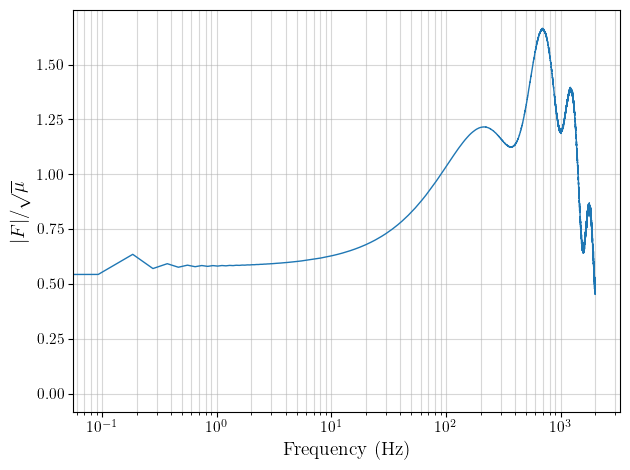

<Axes: xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [41]:
kwargs_macro = {'source_pos_x': beta0,
                'source_pos_y': beta1,
                'theta_E': thetaE,
                'mu': np.abs(Mus[microtype]),
               }

kwargs_integrator = {'PixelNum': int(40000),
                     'PixelBlockMax': 2000,
                     'WindowSize': 2.*210*thetaE3,
                     'WindowCenterX': MacroImg_ra[microtype],
                     'WindowCenterY': MacroImg_dec[microtype],
                     'T0': T0,
                     'TimeStep': 1e-5/Tscale, 
                     'TimeMax': T0 + .7/Tscale,
                     'TimeMin': T0 - .1/Tscale,
                     'TimeLength': .8/Tscale,
                     'TExtend': 10/Tscale,
                     'LastImageT': .02/Tscale,
                     'Tbuffer': .1/Tscale,
                     'Tscale': Tscale}


amplification = af.amplification_factor(lens_model_list=lens_model_list, kwargs_lens=kwargs_lens_list, kwargs_macro=kwargs_macro, **kwargs_integrator)
ts, Ft = amplification.integrator(gpu=False)
ws, Fws = amplification.fourier()
amplification.plot_freq()

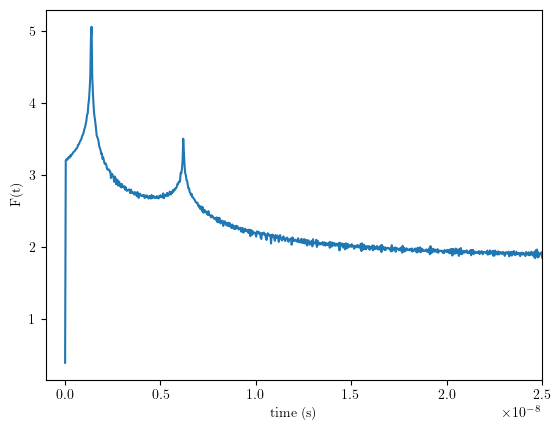

In [60]:
plt.plot(ts, Ft)
plt.xlim(-0.1e-8, 0.25e-7)
plt.xlabel('time (s)')
plt.ylabel('F(t)')
plt.savefig('Ft.pdf')

<Figure size 640x480 with 0 Axes>

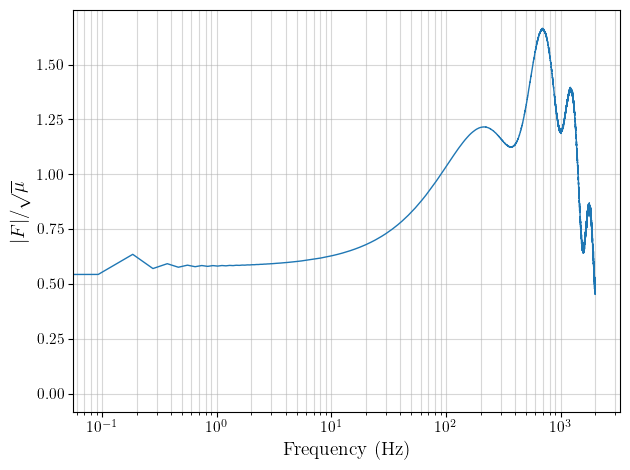

<Axes: xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [43]:
amplification.plot_freq(smooth=False)

<Figure size 640x480 with 0 Axes>

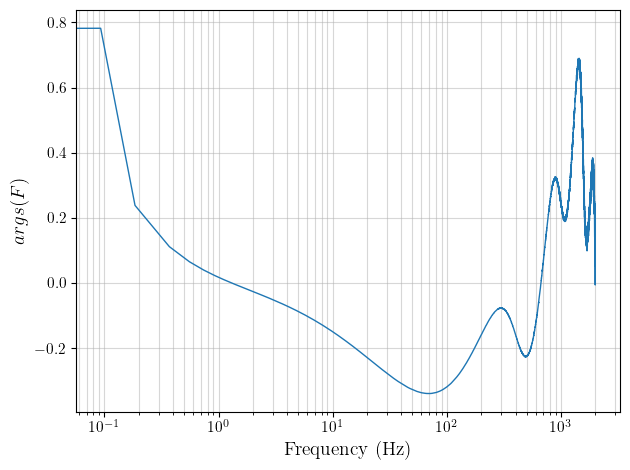

<Axes: xlabel='Frequency (Hz)', ylabel='$args(F)$'>

In [44]:
amplification.plot_freq(pha=True, smooth=False)

# Geometrical optics
To get the geometrical optics around type 1 image, we need the magnifications, time delay and the image positions of the microimages

In [45]:
tds = TimeDelay(Img_ra, Img_dec,
               beta0, beta1,
               zL, zS,
               lens_model_list, kwargs_lens_list)
mus = magnifications(Img_ra, Img_dec, lens_model_list, kwargs_lens_list)
ns = getMinMaxSaddle(Img_ra, Img_dec, lens_model_list, kwargs_lens_list, diff = None)

In [46]:
Img_ra, Img_dec

(array([1.20792073e-06, 1.20792073e-06, 1.20788207e-06, 1.20800930e-06]),
 array([-1.01351045e-10,  1.01351045e-10, -5.71347436e-22, -5.71347436e-22]))

In [47]:
geofs, geoFws = amplification.geometrical_optics(mus, tds, Img_ra, Img_dec, upper_lim=2000)

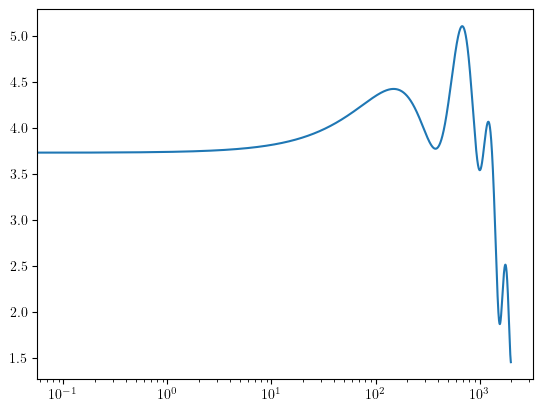

In [48]:
plt.semilogx(geofs, np.abs(geoFws))

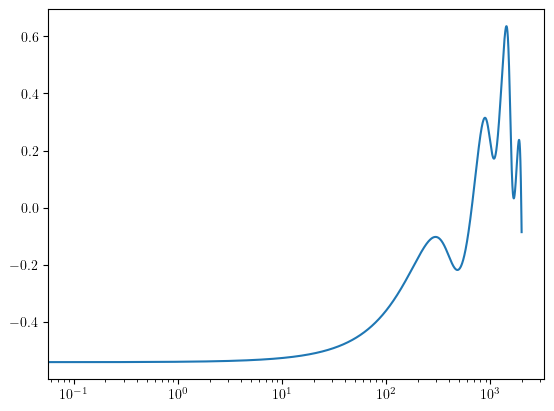

In [49]:
plt.semilogx(geofs, np.angle(geoFws))

# Full amplification factor concatenated with geometrical optics
Given the computaional cost of the diffraction integral, we concatenate the result of wave optics at low frequency and geometrical optics at high frequency to obtain a full amplification factor with default upper bound of 3000Hz.

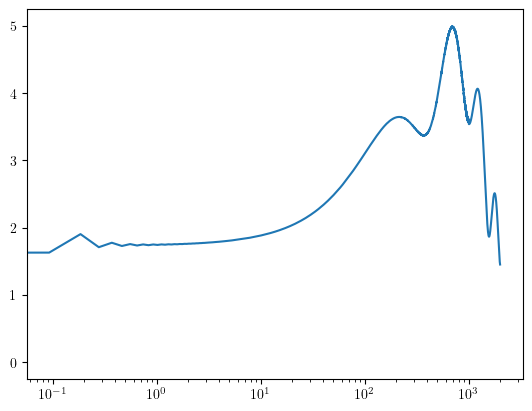

In [50]:
fullfs, fullFws = amplification.concatenate()
plt.semilogx(fullfs, np.abs(fullFws))

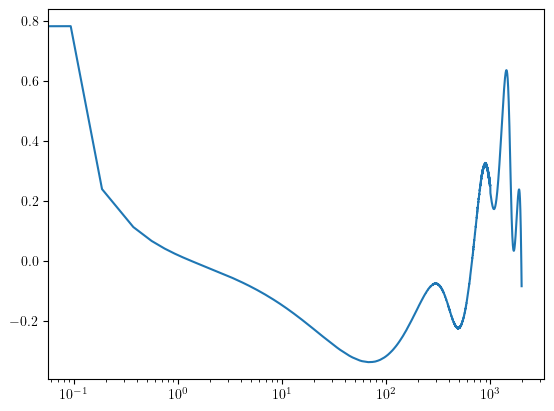

In [51]:
plt.semilogx(fullfs, np.angle(fullFws))

In [52]:
fac = np.sqrt(np.abs(Mus[microtype]))

In [53]:
plt.clf()
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

<Figure size 640x480 with 0 Axes>

In [54]:
from bisect import bisect_left
low_index = bisect_left(geofs, 1)
geofs = geofs[low_index:]
geoFws = geoFws[low_index:]
ws = ws[low_index:]
Fws = Fws[low_index:]

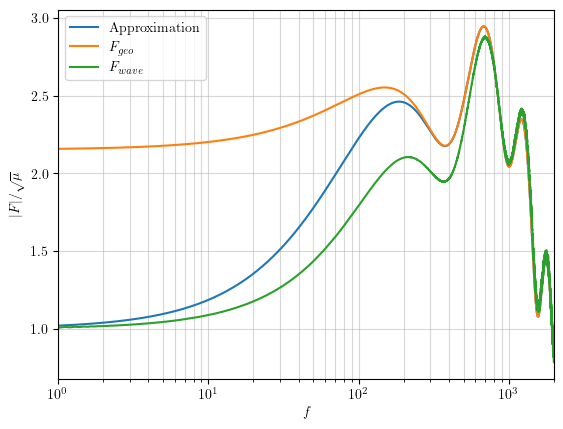

In [56]:
ww = geofs
plt.semilogx(geofs, (fac*np.exp(-ww*np.pi/188) + (1-np.exp(-ww*np.pi/188))*np.abs(geoFws))/fac, label='Approximation')
plt.semilogx(geofs, np.abs(geoFws)/fac,label=r'$F_{geo}$')
plt.semilogx(ws, np.abs(Fws)/fac, label=r'$F_{wave}$')
plt.ylabel(r'$|F|/\sqrt{\mu}$')
plt.xlabel(r'$f$')
plt.grid(which='both', alpha=0.5)
plt.legend()
plt.xlim(1, 2000)
plt.savefig('./approx.pdf',bbox_inches='tight', dpi=300)

(1, 2000)

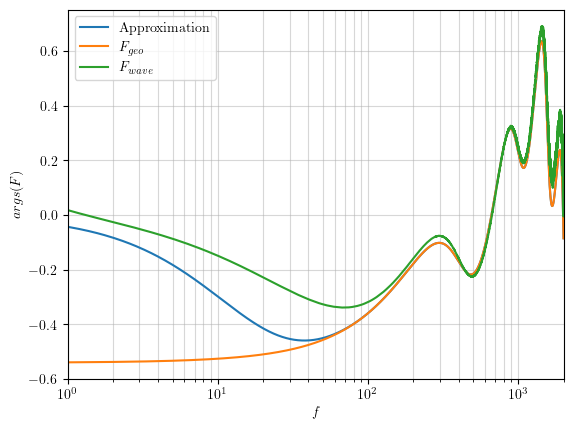

In [49]:
plt.semilogx(geofs, (1-np.exp(-ww*np.pi/37.5))*np.angle(geoFws), label='Approximation')
plt.semilogx(geofs, np.angle(geoFws),label=r'$F_{geo}$')
plt.semilogx(ws, np.angle(Fws), label=r'$F_{wave}$')
plt.ylabel(r'$args(F)$')
plt.xlabel(r'$f$')
plt.grid(which='both', alpha=0.5)
plt.legend()
plt.xlim(1, 2000)
# plt.savefig('./approx_ang.png',bbox_inches='tight', dpi=300)

In [50]:
Abs = (fac*np.exp(-ww*np.pi/1000) + (1-np.exp(-ww*np.pi/1000))*np.abs(geoFws))/fac
Pha = (1-np.exp(-ww*np.pi/1000))*np.angle(geoFws)
complete_approx = Abs * np.exp(1j * Pha)

<Figure size 640x480 with 0 Axes>

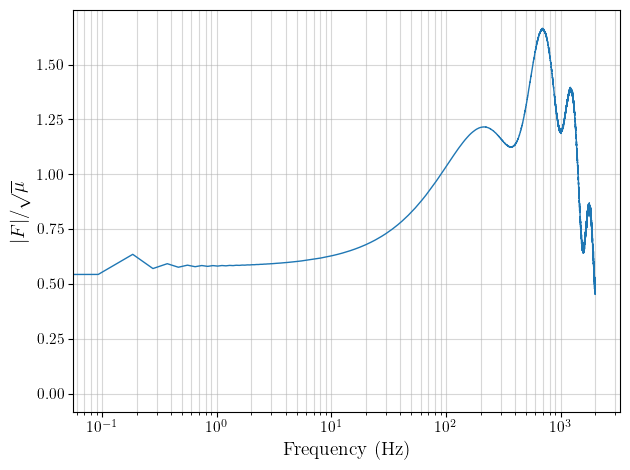

<Axes: xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [51]:
amplification.plot_freq()

<Figure size 640x480 with 0 Axes>

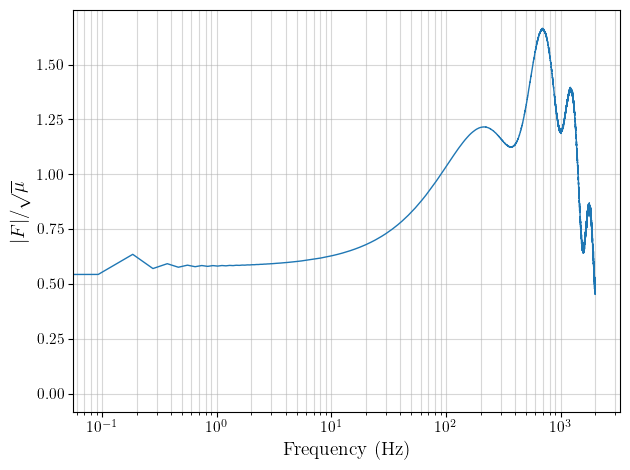

<Axes: xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [52]:
amplification.plot_freq(smooth=False)

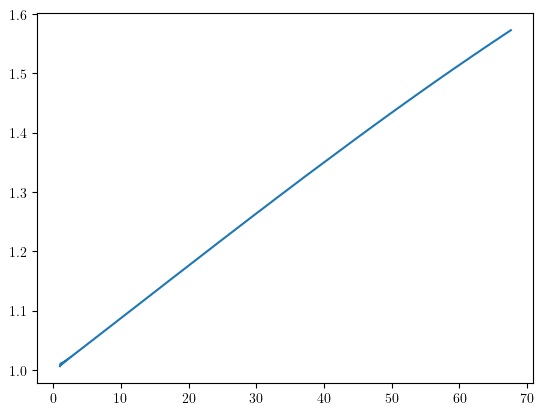

In [53]:
plt.plot(ws[:720], np.abs(Fws[:720])/np.sqrt(3))

In [54]:
from bisect import bisect_left
i = bisect_left(ws, 60)


In [55]:
i

637

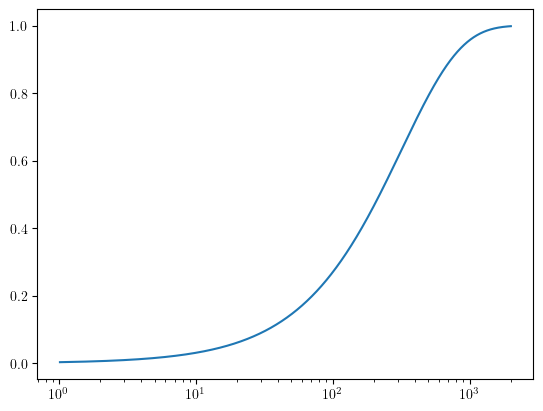

In [56]:
plt.semilogx(ww,(1-np.exp(-ww*np.pi/1000)))

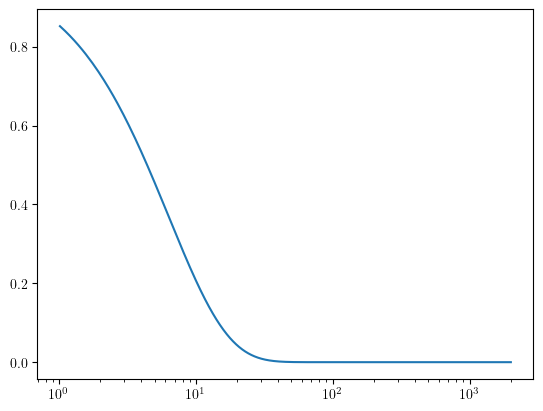

In [57]:
plt.semilogx(ww, np.exp(-ww*np.pi/20))

In [58]:
import pycbc.psd as psd
from pycbc.filter.matchedfilter import overlap, match

hp, hc = get_fd_waveform(approximant = 'IMRPhenomXPHM',
                         mass1 = 30,
                         mass2 = 30,
                         delta_f = .04,
                         f_lower = 10,
                         f_final = 2000)
dfnoise = 0.04
noiselen = int(2001/dfnoise)+1
noise2 = psd.analytical.aLIGOaLIGODesignSensitivityT1800044(noiselen, dfnoise, 1)
noisef = np.linspace(1, 1 + dfnoise*(noiselen-1), num = noiselen)

/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


NameError: name 'get_fd_waveform' is not defined

In [ ]:
np.savetxt('gf.txt', geofs)
np.savetxt('complete.txt', complete_approx)
np.savetxt('ws.txt', ws)
np.savetxt('Fws.txt', Fws)

In [ ]:
np.savetxt('gwoF.txt', geoFws)

In [ ]:
mus, tds, ns

In [ ]:
Img_ra

In [ ]:
from wolensing.utils.utils import *
Morse_indices(amplification._lens_model_list, Img_ra, Img_dec, amplification._kwargs_lens)

In [ ]:
plt.plot(geofs, -0.000435*geofs + np.pi - 23/geofs)